# CEMVI: Sensitivity comparisons

## Room heat inputs

For every hour:

$$Q_{\text{room}}=Q_A+Q_B+Q_{\text{sun}}$$

I will test four alternatives to the original fictional cooling-load table:

1. Reduce equipment A and B heat together by 20%; leave sunlight heat unchanged.
2. Increase equipment A and B heat together by 20%; leave sunlight heat unchanged.
3. Reduce sunlight heat by 20%; leave both equipment heat inputs unchanged.
4. Increase sunlight heat by 20%; leave both equipment heat inputs unchanged.

Only one type of input changes in each alternative. The original CSV remains my baseline. Each row represents a one-hour average, so adding 24 hourly kW values gives kWh of thermal energy for this fictional day.

Scenario              Peak (kW)   Daily heat (kWh thermal)
Baseline                   33.0                      547.0
Equipment −20%             27.6                      446.0
Equipment +20%             38.4                      648.0
Sun heat −20%              31.8                      538.6
Sun heat +20%              34.2                      555.4


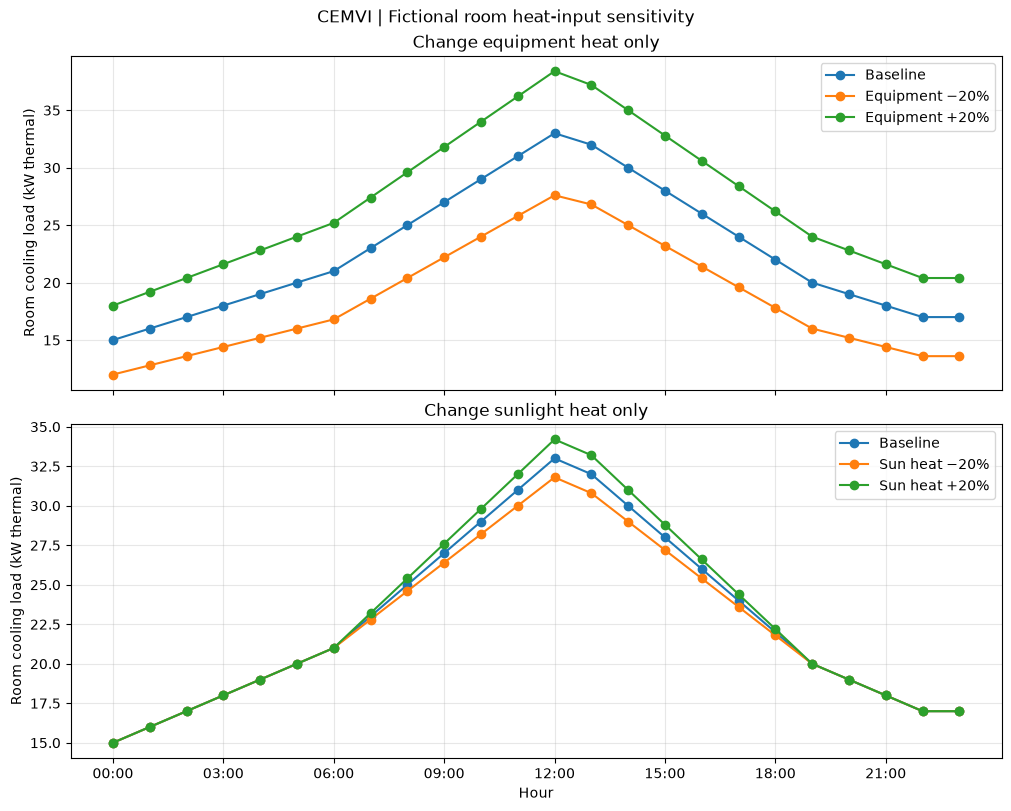

Graph saved: ..\figures\10_room_heat_sensitivity.png


In [1]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt

possible_paths = [
    Path("../data/cooling_demand.csv"),
    Path("data/cooling_demand.csv"),
]
csv_path = next((p for p in possible_paths if p.is_file()), None)

if csv_path is None:
    raise FileNotFoundError("Could not find data/cooling_demand.csv")

with csv_path.open(newline="", encoding="utf-8-sig") as file:
    rows = list(csv.DictReader(file))

if len(rows) != 24:
    raise ValueError("Expected 24 hourly rows.")

hours = [row["hour"] for row in rows]
equipment_a = [float(row["equipment_a_kw"]) for row in rows]
equipment_b = [float(row["equipment_b_kw"]) for row in rows]
sun_heat = [float(row["solar_kw"]) for row in rows]
csv_totals = [float(row["total_kw"]) for row in rows]

baseline = [
    a + b + sun
    for a, b, sun in zip(equipment_a, equipment_b, sun_heat)
]

if any(
    abs(calculated - recorded) > 0.001
    for calculated, recorded in zip(baseline, csv_totals)
):
    raise ValueError("A row does not match the total_kw column.")

scenarios = {
    "Baseline": baseline,
    "Equipment −20%": [
        0.8 * (a + b) + sun
        for a, b, sun in zip(equipment_a, equipment_b, sun_heat)
    ],
    "Equipment +20%": [
        1.2 * (a + b) + sun
        for a, b, sun in zip(equipment_a, equipment_b, sun_heat)
    ],
    "Sun heat −20%": [
        a + b + 0.8 * sun
        for a, b, sun in zip(equipment_a, equipment_b, sun_heat)
    ],
    "Sun heat +20%": [
        a + b + 1.2 * sun
        for a, b, sun in zip(equipment_a, equipment_b, sun_heat)
    ],
}

print(f"{'Scenario':<18} {'Peak (kW)':>12} {'Daily heat (kWh thermal)':>26}")
for name, hourly_loads in scenarios.items():
    daily_heat_kwh = sum(hourly_loads) * 1  # Each row lasts one hour.
    print(
        f"{name:<18} {max(hourly_loads):>12.1f} "
        f"{daily_heat_kwh:>26.1f}"
    )

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True, constrained_layout=True
)
hour_numbers = list(range(24))

for name in ["Baseline", "Equipment −20%", "Equipment +20%"]:
    ax1.plot(hour_numbers, scenarios[name], marker="o", label=name)

for name in ["Baseline", "Sun heat −20%", "Sun heat +20%"]:
    ax2.plot(hour_numbers, scenarios[name], marker="o", label=name)

ax1.set_title("Change equipment heat only")
ax2.set_title("Change sunlight heat only")

for ax in (ax1, ax2):
    ax.set_ylabel("Room cooling load (kW thermal)")
    ax.grid(alpha=0.3)
    ax.legend()

tick_positions = list(range(0, 24, 3))
ax2.set_xticks(tick_positions)
ax2.set_xticklabels([hours[i] for i in tick_positions])
ax2.set_xlabel("Hour")

fig.suptitle("CEMVI | Fictional room heat-input sensitivity")

figure_path = (
    csv_path.parent.parent
    / "figures"
    / "10_room_heat_sensitivity.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=150)
plt.show()

print(f"Graph saved: {figure_path}")

## Graph observation

In this invented day, changing both equipment heat inputs by 20% changes the daily heat to remove by 101 kWh thermal in either direction. Changing sunlight heat by 20% changes it by 8.4 kWh thermal. Equipment heat therefore has the larger effect on this particular invented cooling-load profile.

These are sensitivity comparisons, not measured room conditions. I changed one input type at a time and did not change chiller efficiency or PV electricity.

## Chiller COP sensitivity

For each hour, my cooling-system electricity model is:

$$P_{\text{system}}=\frac{Q_{\text{cooling}}}{COP}+1.2+0.6$$

Here, cooling load is in kW thermal; the resulting system power is in kW electrical. The invented AHU fan uses 1.2 kW and the invented chilled-water pump uses 0.6 kW continuously. The outdoor condenser fan is included in the assumed chiller-package COP.

I will keep the original 24-hour cooling loads and the fan and pump powers fixed. First I will vary baseline COP while improved COP stays at 4.0. Then I will vary improved COP while baseline COP stays at 3.0. All COP values are illustrative assumptions.

Daily heat to remove: 547.0 kWh thermal
Daily fan and pump electricity: 43.2 kWh electrical

Case                   Baseline    Improved   Difference
                       kWh elec    kWh elec     kWh elec
Baseline COP 2.5         262.00      179.95        82.05
Reference                225.53      179.95        45.58
Baseline COP 3.5         199.49      179.95        19.54
Improved COP 3.5         225.53      199.49        26.05
Improved COP 4.5         225.53      164.76        60.78


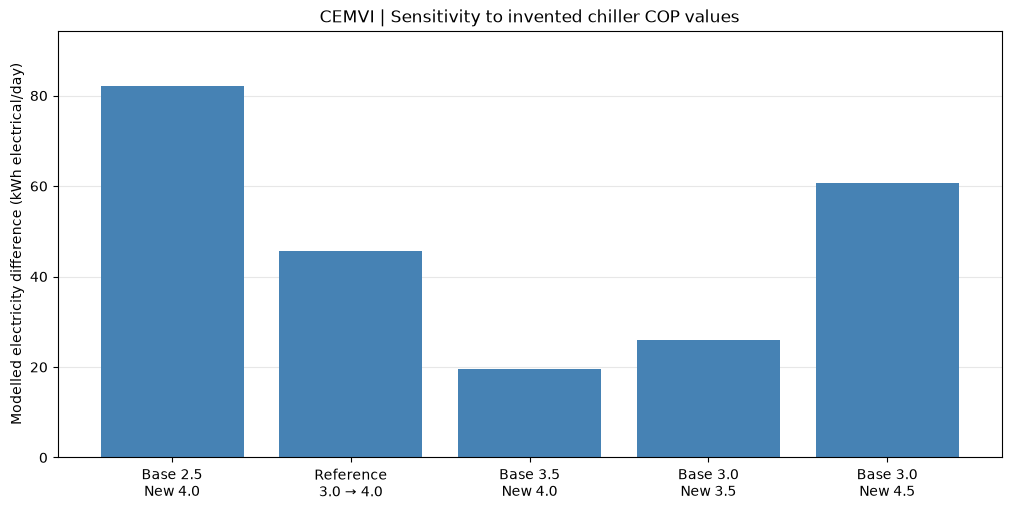


Graph saved: ..\figures\11_cop_sensitivity.png


In [2]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt

possible_paths = [
    Path("../data/cooling_demand.csv"),
    Path("data/cooling_demand.csv"),
]
csv_path = next((p for p in possible_paths if p.is_file()), None)

if csv_path is None:
    raise FileNotFoundError("Could not find data/cooling_demand.csv")

with csv_path.open(newline="", encoding="utf-8-sig") as file:
    rows = list(csv.DictReader(file))

if len(rows) != 24:
    raise ValueError("Expected 24 hourly cooling-load rows.")

cooling_load_kw = [float(row["total_kw"]) for row in rows]

# These are the same invented auxiliary powers used earlier on.
ahu_fan_kw = 1.2
water_pump_kw = 0.6

def daily_system_electricity_kwh(cop):
    if cop <= 0:
        raise ValueError("COP must be greater than zero.")

    # Each CSV row represents one hour.
    return sum(
        (load / cop + ahu_fan_kw + water_pump_kw) * 1
        for load in cooling_load_kw
    )

cases = [
    ("Baseline COP 2.5", 2.5, 4.0, "Base 2.5\nNew 4.0"),
    ("Reference",        3.0, 4.0, "Reference\n3.0 → 4.0"),
    ("Baseline COP 3.5", 3.5, 4.0, "Base 3.5\nNew 4.0"),
    ("Improved COP 3.5", 3.0, 3.5, "Base 3.0\nNew 3.5"),
    ("Improved COP 4.5", 3.0, 4.5, "Base 3.0\nNew 4.5"),
]

print(f"Daily heat to remove: {sum(cooling_load_kw):.1f} kWh thermal")
print(f"Daily fan and pump electricity: {(ahu_fan_kw + water_pump_kw) * 24:.1f} kWh electrical")
print()
print(
    f"{'Case':<19} {'Baseline':>11} "
    f"{'Improved':>11} {'Difference':>12}"
)
print(
    f"{'':<19} {'kWh elec':>11} "
    f"{'kWh elec':>11} {'kWh elec':>12}"
)

plot_labels = []
differences_kwh = []

for name, baseline_cop, improved_cop, plot_label in cases:
    baseline_kwh = daily_system_electricity_kwh(baseline_cop)
    improved_kwh = daily_system_electricity_kwh(improved_cop)
    difference_kwh = baseline_kwh - improved_kwh

    print(
        f"{name:<19} {baseline_kwh:>11.2f} "
        f"{improved_kwh:>11.2f} {difference_kwh:>12.2f}"
    )

    plot_labels.append(plot_label)
    differences_kwh.append(difference_kwh)

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.bar(plot_labels, differences_kwh, color="steelblue")
ax.set_title("CEMVI | Sensitivity to invented chiller COP values")
ax.set_ylabel("Modelled electricity difference (kWh electrical/day)")
ax.set_ylim(0, max(differences_kwh) * 1.15)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

figure_path = (
    csv_path.parent.parent
    / "figures"
    / "11_cop_sensitivity.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=150)
plt.show()

print(f"\nGraph saved: {figure_path}")

## Graph observation

With the original invented cooling profile, baseline COP 3.0 gives 225.53 kWh electrical/day and improved COP 4.0 gives 179.95 kWh electrical/day. The modelled difference is 45.58 kWh electrical/day.

The size of that difference depends strongly on the COP assumptions. For example, keeping improved COP at 4.0 but raising baseline COP to 3.5 reduces the modelled difference to about 19.54 kWh electrical/day. The direction remains the same in the cases tested because improved COP is higher than baseline COP.

These are scenario calculations, not measured electricity savings. I assume COP remains constant across all 24 hours and keep the 1.2 kW AHU fan and 0.6 kW pump unchanged. Electricity for fictional equipment A and B is outside this cooling-system boundary.

## PV size and timing sensitivity

I keep the original fictional cooling loads, baseline chiller COP 3.0, AHU fan 1.2 kW, and chilled-water pump 0.6 kW fixed.

I compare the original invented PV profile with four changes:

1. PV output at 75% of its original hourly values.
2. PV output at 125% of its original hourly values.
3. The original PV profile shifted one hour earlier, keeping its daily production at 101 kWh.
4. The original PV profile shifted one hour later, keeping its daily production at 101 kWh.

For each hour, direct PV use is the smaller of PV supply and cooling-system demand. Grid supply covers the remaining demand; any PV beyond demand is unused in this no-battery comparison.

PV electricity in `data/pv_supply.csv` is separate from the sunlight heat entering the room in `data/cooling_demand.csv`.

Cooling-system demand: 225.53 kWh electrical

Scenario            PV made   PV used      Grid   PV unused
                        kWh       kWh       kWh         kWh
Original             101.00     84.20    141.33       16.80
PV 75%                75.75     74.02    151.52        1.73
PV 125%              126.25     90.55    134.98       35.70
1 hour earlier       101.00     83.87    141.67       17.13
1 hour later         101.00     83.20    142.33       17.80


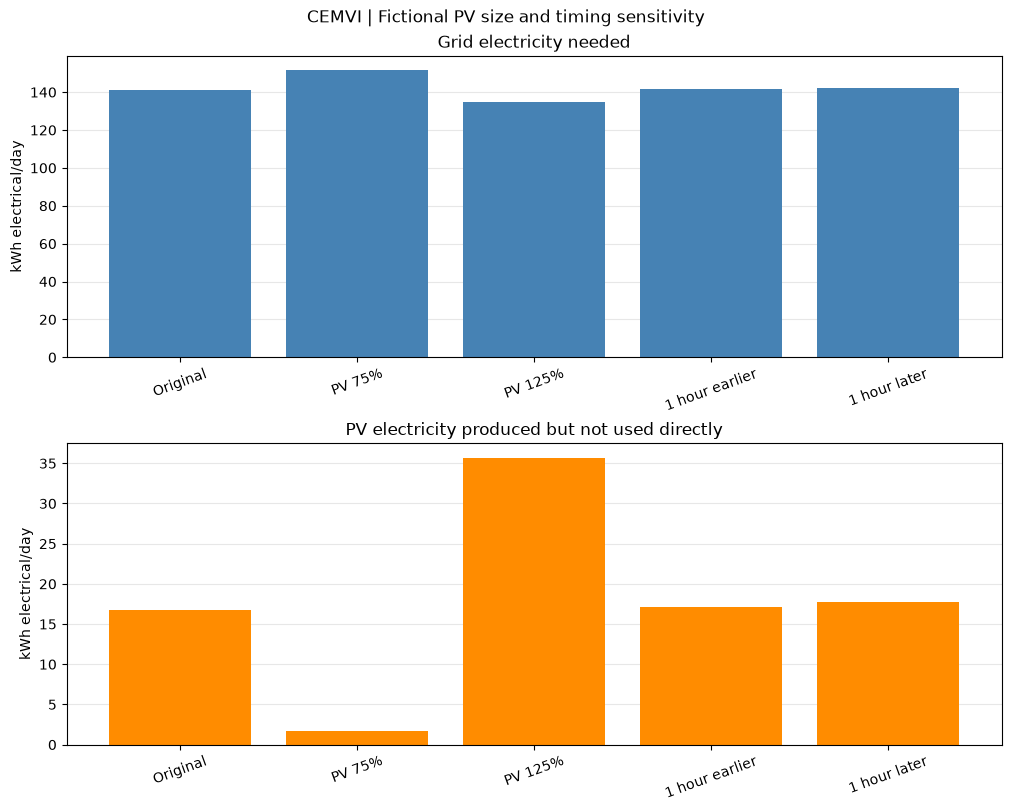


Graph saved: ..\figures\12_pv_sensitivity.png


In [3]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt

def find_file(filename):
    for path in [Path("../data") / filename, Path("data") / filename]:
        if path.is_file():
            return path
    raise FileNotFoundError(f"Could not find {filename} in the data folder.")

cooling_path = find_file("cooling_demand.csv")
pv_path = find_file("pv_supply.csv")

with cooling_path.open(newline="", encoding="utf-8-sig") as file:
    cooling_rows = list(csv.DictReader(file))

with pv_path.open(newline="", encoding="utf-8-sig") as file:
    pv_rows = list(csv.DictReader(file))

cooling_hours = [row["hour"] for row in cooling_rows]
pv_hours = [row["hour"] for row in pv_rows]

if len(cooling_rows) != 24 or cooling_hours != pv_hours:
    raise ValueError("Expected the same 24 hours in both CSV files.")

cooling_load_kw = [
    float(row["total_kw"]) for row in cooling_rows
]
original_pv_kw = [
    float(row["pv_kw"]) for row in pv_rows
]

# Hold the original cooling-system demand fixed.
demand_kw = [
    load / 3.0 + 1.2 + 0.6
    for load in cooling_load_kw
]

# A shifted profile keeps its daily total because the first
# and final hours of the original PV profile are both zero.
if original_pv_kw[0] != 0 or original_pv_kw[-1] != 0:
    raise ValueError("Check PV end hours before shifting the profile.")

pv_scenarios = {
    "Original": original_pv_kw,
    "PV 75%": [0.75 * value for value in original_pv_kw],
    "PV 125%": [1.25 * value for value in original_pv_kw],
    "1 hour earlier": [
        original_pv_kw[i + 1] if i < 23 else 0.0
        for i in range(24)
    ],
    "1 hour later": [
        original_pv_kw[i - 1] if i > 0 else 0.0
        for i in range(24)
    ],
}

results = {}

for name, supply_kw in pv_scenarios.items():
    direct_use_kw = [
        min(demand, supply)
        for demand, supply in zip(demand_kw, supply_kw)
    ]
    grid_kw = [
        max(demand - supply, 0)
        for demand, supply in zip(demand_kw, supply_kw)
    ]
    unused_kw = [
        max(supply - demand, 0)
        for demand, supply in zip(demand_kw, supply_kw)
    ]

    # Every row lasts one hour: summed kW values give daily kWh.
    produced = sum(supply_kw)
    used = sum(direct_use_kw)
    grid = sum(grid_kw)
    unused = sum(unused_kw)

    if abs((used + grid) - sum(demand_kw)) > 0.000001:
        raise ValueError(f"Cooling electricity balance failed: {name}")
    if abs((used + unused) - produced) > 0.000001:
        raise ValueError(f"PV electricity balance failed: {name}")

    results[name] = {
        "produced": produced,
        "used": used,
        "grid": grid,
        "unused": unused,
    }

print(f"Cooling-system demand: {sum(demand_kw):.2f} kWh electrical")
print()
print(
    f"{'Scenario':<17} {'PV made':>9} {'PV used':>9} "
    f"{'Grid':>9} {'PV unused':>11}"
)
print(
    f"{'':<17} {'kWh':>9} {'kWh':>9} "
    f"{'kWh':>9} {'kWh':>11}"
)

for name, values in results.items():
    print(
        f"{name:<17} {values['produced']:>9.2f} "
        f"{values['used']:>9.2f} {values['grid']:>9.2f} "
        f"{values['unused']:>11.2f}"
    )

names = list(results)
grid_values = [results[name]["grid"] for name in names]
unused_values = [results[name]["unused"] for name in names]

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 8), constrained_layout=True
)

ax1.bar(names, grid_values, color="steelblue")
ax1.set_title("Grid electricity needed")
ax1.set_ylabel("kWh electrical/day")
ax1.set_ylim(bottom=0)
ax1.grid(axis="y", alpha=0.3)

ax2.bar(names, unused_values, color="darkorange")
ax2.set_title("PV electricity produced but not used directly")
ax2.set_ylabel("kWh electrical/day")
ax2.set_ylim(bottom=0)
ax2.grid(axis="y", alpha=0.3)

for ax in (ax1, ax2):
    ax.set_axisbelow(True)
    ax.tick_params(axis="x", labelrotation=20)

fig.suptitle("CEMVI | Fictional PV size and timing sensitivity")

figure_path = (
    cooling_path.parent.parent
    / "figures"
    / "12_pv_sensitivity.png"
)
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=150)
plt.show()

print(f"\nGraph saved: {figure_path}")

## Graph observation

The original fictional PV profile produces 101.00 kWh electrical. Of this, 84.20 kWh meets cooling-system demand in the same hours, 16.80 kWh is unused directly, and the grid supplies 141.33 kWh.

Making the PV profile 25% larger raises daily production to 126.25 kWh, but direct use rises only to 90.55 kWh; unused PV also rises. Shifting the unchanged 101 kWh profile by one hour changes direct use and grid supply. This shows that hourly timing matters as well as total PV production.

These are invented, no-battery comparisons. The cooling load, COP, AHU fan, pump, and sunlight heat entering the room remain unchanged. This is an hourly electricity balance, not a prediction of actual PV generation.

## Material and arm-thickness sensitivity

For both steel and aluminium, I test Young's modulus at 90%, 100%, and 110% of its logged value while keeping all dimensions unchanged.

Separately, I test vertical arm thickness at 9 mm, 10 mm, and 11 mm while keeping Young's modulus unchanged. The arm's length remains 300 mm, width remains 50 mm, and static tip force remains 100 N.

I compare arm mass, tip deflection under 100 N, and the simplified natural frequency with the same 10 kg attached module. These ±10% changes are invented sensitivity tests, not material-property or manufacturing tolerances.


Steel
  E -10%    mass=1.185 kg, deflection=1.200 mm, natural frequency=14.53 Hz
  Original  mass=1.185 kg, deflection=1.080 mm, natural frequency=15.31 Hz
  E +10%    mass=1.185 kg, deflection=0.982 mm, natural frequency=16.06 Hz
  h -10%    mass=1.067 kg, deflection=1.481 mm, natural frequency=13.08 Hz
  h +10%    mass=1.304 kg, deflection=0.811 mm, natural frequency=17.67 Hz

Aluminium
  E -10%    mass=0.405 kg, deflection=3.478 mm, natural frequency=8.53 Hz
  Original  mass=0.405 kg, deflection=3.130 mm, natural frequency=9.00 Hz
  E +10%    mass=0.405 kg, deflection=2.846 mm, natural frequency=9.43 Hz
  h -10%    mass=0.364 kg, deflection=4.294 mm, natural frequency=7.68 Hz
  h +10%    mass=0.446 kg, deflection=2.352 mm, natural frequency=10.38 Hz


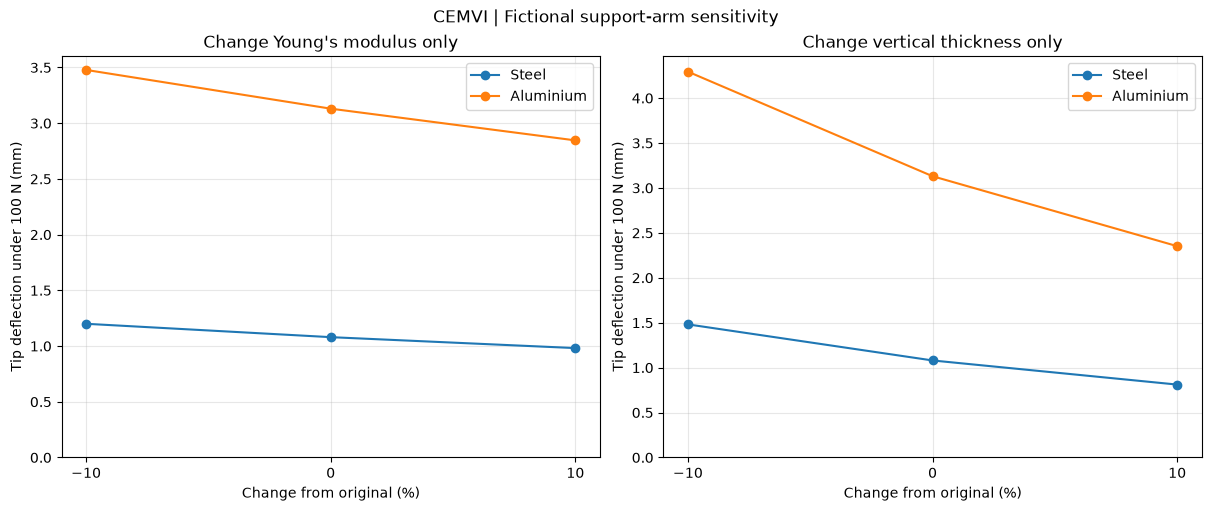


Graph saved: ..\figures\13_support_sensitivity.png


In [4]:
from pathlib import Path
import math
import matplotlib.pyplot as plt

# Original geometry and static force
length_m = 0.300
width_m = 0.050
original_thickness_m = 0.010
static_force_n = 100.0

# Earlier simplified vibration input
attached_mass_kg = 10.0

# Public material values already recorded in the source log
materials = {
    "Steel": {"youngs_pa": 200e9, "density_kg_m3": 7900},
    "Aluminium": {"youngs_pa": 69e9, "density_kg_m3": 2700},
}

# Change only E OR thickness in each case.
scenarios = [
    ("E -10%", 0.90, 1.00),
    ("Original", 1.00, 1.00),
    ("E +10%", 1.10, 1.00),
    ("h -10%", 1.00, 0.90),
    ("h +10%", 1.00, 1.10),
]

def calculate(youngs_pa, density_kg_m3, thickness_m):
    volume_m3 = length_m * width_m * thickness_m
    arm_mass_kg = density_kg_m3 * volume_m3

    second_moment_m4 = width_m * thickness_m**3 / 12
    tip_stiffness_n_m = (
        3 * youngs_pa * second_moment_m4 / length_m**3
    )
    tip_deflection_mm = (
        static_force_n / tip_stiffness_n_m * 1000
    )
    natural_frequency_hz = (
        math.sqrt(tip_stiffness_n_m / attached_mass_kg)
        / (2 * math.pi)
    )

    return arm_mass_kg, tip_deflection_mm, natural_frequency_hz

results = {}

for material, properties in materials.items():
    print(f"\n{material}")

    for label, e_multiplier, h_multiplier in scenarios:
        values = calculate(
            properties["youngs_pa"] * e_multiplier,
            properties["density_kg_m3"],
            original_thickness_m * h_multiplier,
        )
        results[(material, label)] = values
        arm_mass, deflection, natural_hz = values

        print(
            f"  {label:<9} mass={arm_mass:.3f} kg, "
            f"deflection={deflection:.3f} mm, "
            f"natural frequency={natural_hz:.2f} Hz"
        )

changes_percent = [-10, 0, 10]
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True
)

for material in materials:
    e_deflections = [
        results[(material, label)][1]
        for label in ["E -10%", "Original", "E +10%"]
    ]
    h_deflections = [
        results[(material, label)][1]
        for label in ["h -10%", "Original", "h +10%"]
    ]

    ax1.plot(
        changes_percent, e_deflections,
        marker="o", label=material
    )
    ax2.plot(
        changes_percent, h_deflections,
        marker="o", label=material
    )

ax1.set_title("Change Young's modulus only")
ax2.set_title("Change vertical thickness only")

for ax in (ax1, ax2):
    ax.set_xlabel("Change from original (%)")
    ax.set_ylabel("Tip deflection under 100 N (mm)")
    ax.set_xticks(changes_percent)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("CEMVI | Fictional support-arm sensitivity")

figure_folder = (
    Path("../figures")
    if Path("../data").is_dir()
    else Path("figures")
)
figure_folder.mkdir(parents=True, exist_ok=True)
figure_path = figure_folder / "13_support_sensitivity.png"

fig.savefig(figure_path, dpi=150)
plt.show()
print(f"\nGraph saved: {figure_path}")

## Graph observation

In these one-at-a-time ±10% tests, changing vertical thickness affects tip deflection more strongly than changing Young's modulus by the same percentage. The bending calculation contains thickness cubed, so a small thickness change has a noticeable effect.

Across the tested cases, the aluminium arm remains lighter, while the steel arm has the smaller calculated static deflection. Changing thickness also changes the simplified natural frequency. These results apply to the stated fictional geometry and assumptions; they do not establish that either arm is safe for construction.

## Vibration force and damping sensitivity

I use the original support stiffnesses used earlier on, a 10 kg attached moving mass, and a 10 Hz repeated push.

First, I test force amplitudes of 3.75 N, 5.00 N, and 6.25 N while holding the damping ratio at 0.10. Separately, I test damping ratios of 0.05, 0.10, and 0.20 while holding force amplitude at 5.00 N.

The 5.00 N force and 0.10 damping ratio are my original invented inputs. The other values are sensitivity tests, not measurements.

Change force only: damping ratio stays at 0.10
 Force (N)    Steel (mm)    Aluminium (mm)
      3.75         0.069             0.362
      5.00         0.092             0.483
      6.25         0.115             0.604

Change damping only: force stays at 5.00 N
   Damping    Steel (mm)    Aluminium (mm)
        5%         0.094             0.600
       10%         0.092             0.483
       20%         0.086             0.311


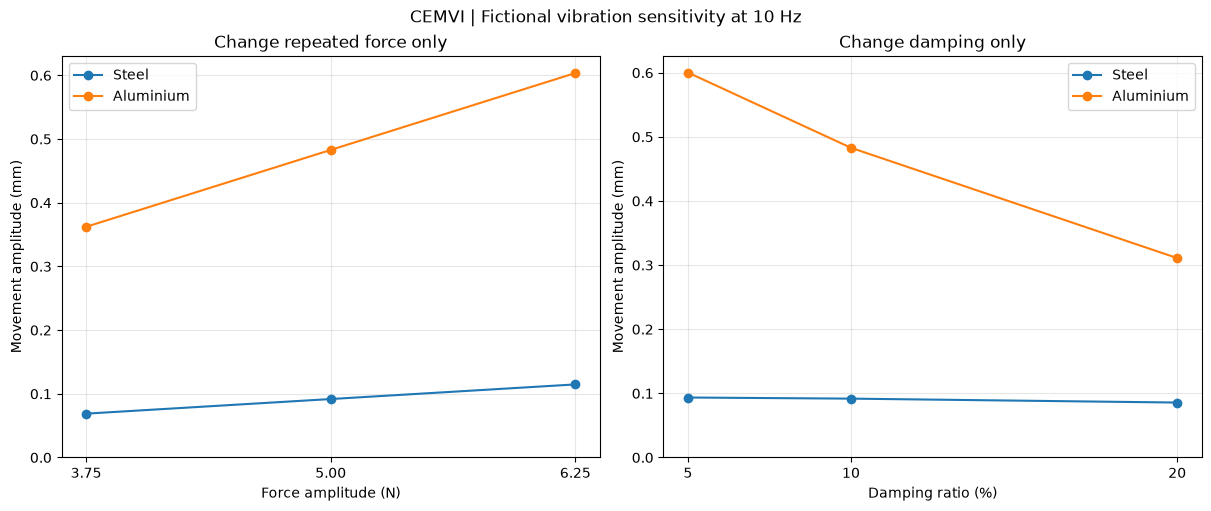


Graph saved: ..\figures\14_vibration_input_sensitivity.png


In [5]:
from pathlib import Path
import math
import matplotlib.pyplot as plt

# Original vibration inputs
moving_mass_kg = 10.0
push_frequency_hz = 10.0
omega = 2 * math.pi * push_frequency_hz

stiffness_n_m = {
    "Steel": 92592.59,
    "Aluminium": 31944.44,
}

force_cases_n = [3.75, 5.00, 6.25]
damping_cases_percent = [5, 10, 20]

def movement_amplitude_mm(stiffness, force_n, damping_ratio):
    damping_n_s_m = (
        2 * damping_ratio * math.sqrt(stiffness * moving_mass_kg)
    )
    denominator = math.hypot(
        stiffness - moving_mass_kg * omega**2,
        damping_n_s_m * omega,
    )
    return 1000 * force_n / denominator

print("Change force only: damping ratio stays at 0.10")
print(f"{'Force (N)':>10} {'Steel (mm)':>13} {'Aluminium (mm)':>17}")

for force_n in force_cases_n:
    steel = movement_amplitude_mm(
        stiffness_n_m["Steel"], force_n, 0.10
    )
    aluminium = movement_amplitude_mm(
        stiffness_n_m["Aluminium"], force_n, 0.10
    )
    print(f"{force_n:>10.2f} {steel:>13.3f} {aluminium:>17.3f}")

print()
print("Change damping only: force stays at 5.00 N")
print(f"{'Damping':>10} {'Steel (mm)':>13} {'Aluminium (mm)':>17}")

for damping_percent in damping_cases_percent:
    ratio = damping_percent / 100
    steel = movement_amplitude_mm(
        stiffness_n_m["Steel"], 5.00, ratio
    )
    aluminium = movement_amplitude_mm(
        stiffness_n_m["Aluminium"], 5.00, ratio
    )
    print(
        f"{damping_percent:>9}% {steel:>13.3f} "
        f"{aluminium:>17.3f}"
    )

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(12, 5), constrained_layout=True
)

for material, stiffness in stiffness_n_m.items():
    force_movements = [
        movement_amplitude_mm(stiffness, force_n, 0.10)
        for force_n in force_cases_n
    ]
    damping_movements = [
        movement_amplitude_mm(stiffness, 5.00, percent / 100)
        for percent in damping_cases_percent
    ]

    ax1.plot(
        force_cases_n, force_movements, marker="o", label=material
    )
    ax2.plot(
        damping_cases_percent, damping_movements,
        marker="o", label=material
    )

ax1.set_title("Change repeated force only")
ax1.set_xlabel("Force amplitude (N)")
ax1.set_xticks(force_cases_n)

ax2.set_title("Change damping only")
ax2.set_xlabel("Damping ratio (%)")
ax2.set_xticks(damping_cases_percent)

for ax in (ax1, ax2):
    ax.set_ylabel("Movement amplitude (mm)")
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("CEMVI | Fictional vibration sensitivity at 10 Hz")

figure_folder = (
    Path("../figures")
    if Path("../data").is_dir()
    else Path("figures")
)
figure_folder.mkdir(parents=True, exist_ok=True)
figure_path = figure_folder / "14_vibration_input_sensitivity.png"

fig.savefig(figure_path, dpi=150)
plt.show()

print(f"\nGraph saved: {figure_path}")

## Graph observation

When I increase the invented repeated force from 3.75 N to 6.25 N, the calculated movement increases for both arms. Force and movement amplitude are directly proportional in this simplified model when the other inputs stay fixed.

When I increase the damping ratio from 0.05 to 0.20 while holding force at 5 N, the calculated movement decreases. At the chosen 10 Hz push, the aluminium arm is closer to its calculated natural frequency, so changing damping has a larger effect on its result.

The original 5 N and 0.10 damping case reproduces the earlier result: approximately 0.092 mm for steel and 0.483 mm for aluminium. These results describe calculated steady-state movement under invented inputs. They are not measured vibration or a judgement of support safety.

## Results and interpretation

I changed one invented input at a time and compared each result with the original model.

| Test | Original result | What the tested changes showed |
|---|---|---|
| Room heat | 547.0 kWh thermal/day | Changing equipment heat by ±20% moved the result to 446.0–648.0 kWh. Changing sunlight heat by ±20% moved it to 538.6–555.4 kWh. |
| Chiller COP | 45.58 kWh electrical/day difference between COP 3.0 and 4.0 | The calculated difference ranged from 19.54 to 82.05 kWh/day across the tested COP pairs. |
| PV supply | 141.33 kWh/day from the grid | Changing PV size moved grid supply to 134.98–151.52 kWh/day. Shifting the original PV profile by one hour gave 141.67–142.33 kWh/day. |
| Arm thickness | Steel: 1.080 mm; aluminium: 3.130 mm static tip deflection | Changing thickness by ±10% moved steel deflection to 0.811–1.481 mm and aluminium deflection to 2.352–4.294 mm. |
| Vibration at 10 Hz | Steel: 0.092 mm; aluminium: 0.483 mm movement amplitude | Changing force or damping changed both results. For example, changing the damping ratio from 0.05 to 0.20 moved aluminium amplitude from 0.600 to 0.311 mm. |

## What I can conclude within this model

- Equipment heat has a larger effect than sunlight heat on the daily cooling load **for this invented profile and the tested ±20% changes**.
- A higher assumed chiller COP reduces calculated cooling-system electricity use when cooling load and auxiliary powers stay fixed. The size of the difference depends on the COP values chosen.
- More PV production does not all become useful direct supply: some is produced in hours when it exceeds cooling-system demand. Timing also changes direct PV use.
- Vertical arm thickness strongly affects calculated bending because thickness is cubed in the beam-stiffness equation.
- The aluminium arm's calculated vibration at 10 Hz depends noticeably on damping. The material comparison also depends on the chosen push frequency.

## What remains uncertain

All room loads, PV values, COP values, support geometry, forces, and damping inputs describe a fictional case. The tests change one input at a time; they do not show what happens when several inputs change together.

The chiller uses constant COP values, the PV balance has no battery, and the support model represents only one simplified movement. These calculations have not been checked against measured equipment or manufacturer performance data. I therefore cannot claim actual electricity savings, predict real vibration, or decide whether either support is safe to build.

In [6]:
from pathlib import Path
import csv

project_root = next(
    (
        folder for folder in [Path.cwd(), Path.cwd().parent]
        if (folder / "data").is_dir()
        and (folder / "notebooks").is_dir()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError("Open the CEMVI PROJECT folder in VS Code.")

required_folders = [
    "data", "figures", "notebooks", "assumptions.md", "sources.md"
]
required_notebooks = [
    "01_cooling_demand.ipynb",
    "02_material_support.ipynb",
    "03_vibration_model.ipynb",
    "04_sensitivity.ipynb",
]
required_figures = [
    "10_room_heat_sensitivity.png",
    "11_cop_sensitivity.png",
    "12_pv_sensitivity.png",
    "13_support_sensitivity.png",
    "14_vibration_input_sensitivity.png",
]

missing = [
    name for name in required_folders
    if not (project_root / name).is_dir()
]
missing += [
    f"notebooks/{name}" for name in required_notebooks
    if not (project_root / "notebooks" / name).is_file()
]
missing += [
    f"figures/{name}" for name in required_figures
    if not (project_root / "figures" / name).is_file()
]

if missing:
    print("Missing items:")
    for item in missing:
        print(" -", item)
    raise FileNotFoundError("Complete the missing items listed above.")

with (project_root / "data" / "cooling_demand.csv").open(
    newline="", encoding="utf-8-sig"
) as file:
    cooling_rows = list(csv.DictReader(file))

with (project_root / "data" / "pv_supply.csv").open(
    newline="", encoding="utf-8-sig"
) as file:
    pv_rows = list(csv.DictReader(file))

cooling_hours = [row["hour"] for row in cooling_rows]
pv_hours = [row["hour"] for row in pv_rows]

if len(cooling_rows) != 24 or cooling_hours != pv_hours:
    raise ValueError("The two CSV files must have the same 24 hours.")

cooling_total = sum(float(row["total_kw"]) for row in cooling_rows)
pv_total = sum(float(row["pv_kw"]) for row in pv_rows)

print("Project folders and four notebooks: FOUND")
print("Figures 10–14: FOUND")
print("Both CSV files: 24 matching hours")
print(f"Original daily cooling heat: {cooling_total:.2f} kWh thermal")
print(f"Original daily PV supply: {pv_total:.2f} kWh electrical")
print("FILE AUDIT PASSED")

Project folders and four notebooks: FOUND
Figures 10–14: FOUND
Both CSV files: 24 matching hours
Original daily cooling heat: 547.00 kWh thermal
Original daily PV supply: 101.00 kWh electrical
FILE AUDIT PASSED


## Fresh-run record

| Notebook | Fresh kernel and Run All | Result |
|---|---|---|
| `01_cooling_demand.ipynb` | Completed | Passed without errors |
| `02_material_support.ipynb` | Completed | Passed without errors |
| `03_vibration_model.ipynb` | Completed | Passed without errors |
| `04_sensitivity.ipynb` | Completed | Passed without errors |

The file audit found all four notebooks and figures 10–14. Both input CSV files contain 24 matching hours. The original daily cooling heat totals **547.00 kWh thermal**, and the original daily PV supply totals **101.00 kWh electrical**.

All four notebooks ran from fresh kernels in order. This confirms that the recorded calculations can run without variables left over from an earlier session. It does not turn the fictional inputs into real equipment measurements.